# BANK LOAN ANALYSIS REPORT

### Import Libraries

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import plotly.express as px

In [5]:
pip install plotly


[notice] A new release of pip is available: 26.0 -> 26.1.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [6]:
df = pd.read_excel("/Users/ayushi/Downloads/Bank loan analysis/financial_loan_data_excel.xlsx")

In [7]:
df.head()

,id,address_state,application_type,emp_length,emp_title,grade,home_ownership,issue_date,last_credit_pull_date,last_payment_date,...,sub_grade,term,verification_status,annual_income,dti,installment,int_rate,loan_amount,total_acc,total_payment
0,1077430,GA,INDIVIDUAL,< 1 year,Ryder,C,RENT,2021-02-11,2021-09-13,2021-04-13,...,C4,60 months,Source Verified,30000.0,0.0100,59.83,0.1527,2500,4,1009
1,1072053,CA,INDIVIDUAL,9 years,MKC Accounting,E,RENT,2021-01-01,2021-12-14,2021-01-15,...,E1,36 months,Source Verified,48000.0,0.0535,109.43,0.1864,3000,4,3939
2,1069243,CA,INDIVIDUAL,4 years,Chemat Technology Inc,C,RENT,2021-01-05,2021-12-12,2021-01-09,...,C5,36 months,Not Verified,50000.0,0.2088,421.65,0.1596,12000,11,3522
3,1041756,TX,INDIVIDUAL,< 1 year,barnes distribution,B,MORTGAGE,2021-02-25,2021-12-12,2021-03-12,...,B2,60 months,Source Verified,42000.0,0.0540,97.06,0.1065,4500,9,4911
4,1068350,IL,INDIVIDUAL,10+ years,J&J Steel Inc,A,MORTGAGE,2021-01-01,2021-12-14,2021-01-15,...,A1,36 months,Verified,83000.0,0.0231,106.53,0.0603,3500,28,3835


### Metadata of data

In [8]:
print("No of Rows:", df.shape[0])

No of Rows: 38576


In [9]:
print("No of columns:", df.shape[1])

No of columns: 24


In [10]:
df.info

<bound method DataFrame.info of             id address_state application_type emp_length  \
0      1077430            GA       INDIVIDUAL   < 1 year   
1      1072053            CA       INDIVIDUAL    9 years   
2      1069243            CA       INDIVIDUAL    4 years   
3      1041756            TX       INDIVIDUAL   < 1 year   
4      1068350            IL       INDIVIDUAL  10+ years   
...        ...           ...              ...        ...   
38571   803452            NJ       INDIVIDUAL   < 1 year   
38572   970377            NY       INDIVIDUAL    8 years   
38573   875376            CA       INDIVIDUAL    5 years   
38574   972997            NY       INDIVIDUAL    5 years   
38575   682952            NY       INDIVIDUAL    4 years   

                             emp_title grade home_ownership issue_date  \
0                                Ryder     C           RENT 2021-02-11   
1                       MKC Accounting     E           RENT 2021-01-01   
2                Chemat T

### Data types

In [11]:
df.dtypes

id                                int64
address_state                       str
application_type                    str
emp_length                          str
emp_title                        object
grade                               str
home_ownership                      str
issue_date               datetime64[us]
last_credit_pull_date    datetime64[us]
last_payment_date        datetime64[us]
loan_status                         str
next_payment_date        datetime64[us]
member_id                         int64
purpose                             str
sub_grade                           str
term                                str
verification_status                 str
annual_income                   float64
dti                             float64
installment                     float64
int_rate                        float64
loan_amount                       int64
total_acc                         int64
total_payment                     int64
dtype: object

In [12]:
df.describe()

,id,issue_date,last_credit_pull_date,last_payment_date,next_payment_date,member_id,annual_income,dti,installment,int_rate,loan_amount,total_acc,total_payment
count,3.857600e+04,38576,38576,38576,38576,3.857600e+04,3.857600e+04,38576.000000,38576.000000,38576.000000,38576.000000,38576.000000,38576.000000
mean,6.810371e+05,2021-07-16 02:31:35.562007,2021-06-08 13:36:34.193280,2021-06-26 09:52:08.909166,2021-07-26 20:42:20.605557,8.476515e+05,6.964454e+04,0.133274,326.862965,0.120488,11296.066855,22.132544,12263.348533
min,5.473400e+04,2021-01-01 00:00:00,2021-01-08 00:00:00,2021-01-08 00:00:00,2021-02-08 00:00:00,7.069900e+04,4.000000e+03,0.000000,15.690000,0.054200,500.000000,2.000000,34.000000
25%,5.135170e+05,2021-04-11 00:00:00,2021-04-15 00:00:00,2021-03-16 00:00:00,2021-04-16 00:00:00,6.629788e+05,4.150000e+04,0.082100,168.450000,0.093200,5500.000000,14.000000,5633.000000
50%,6.627280e+05,2021-07-11 00:00:00,2021-05-16 00:00:00,2021-06-14 00:00:00,2021-07-14 00:00:00,8.473565e+05,6.000000e+04,0.134200,283.045000,0.118600,10000.000000,20.000000,10042.000000
75%,8.365060e+05,2021-10-11 00:00:00,2021-08-13 00:00:00,2021-09-15 00:00:00,2021-10-15 00:00:00,1.045652e+06,8.320050e+04,0.185900,434.442500,0.145900,15000.000000,29.000000,16658.000000
max,1.077501e+06,2021-12-12 00:00:00,2022-01-20 00:00:00,2021-12-15 00:00:00,2022-01-15 00:00:00,1.314167e+06,6.000000e+06,0.299900,1305.190000,0.245900,35000.000000,90.000000,58564.000000
std,2.113246e+05,NaN,NaN,NaN,NaN,2.668105e+05,6.429368e+04,0.066662,209.092000,0.037164,7460.746022,11.392282,9051.104777


### Total Loan Applications

In [13]:
total_loan_application = df['id'].count()
print("Total loan Applications:", total_loan_application)

Total loan Applications: 38576


### MTD Total Loan Applications

In [14]:
latest_issue_date = df['issue_date'].max()
latest_year = latest_issue_date.year
latest_month = latest_issue_date.month

mtd_data = df[(df['issue_date'].dt.year == latest_year) & (df['issue_date'].dt.month == latest_month)]

mtd_loan_applications = mtd_data['id'].count()

print(f"MTD Loan Applications(for {latest_issue_date.strftime('%B %Y')}):{mtd_loan_applications}")

MTD Loan Applications(for December 2021):4314


### Total Funded Amount

In [15]:
total_funded_amount = df['loan_amount'].sum()
total_funded_amount_millions = total_funded_amount/ 1000000
print("Total Funded Amount: ${:.2f}M". format(total_funded_amount_millions))

Total Funded Amount: $435.76M


### MTD - Total Funded Amount

In [16]:
latest_issue_date = df['issue_date'].max()
latest_year = latest_issue_date.year
latest_month = latest_issue_date.month

mtd_data = df[(df['issue_date'].dt.year == latest_year) & (df['issue_date'].dt.month == latest_month)]

mtd_total_funded_amount = mtd_data['loan_amount'].sum()
mtd_total_funded_amount_millions = mtd_total_funded_amount/1000000

print("MTD Total Funded Amount: ${:.2f}M". format(mtd_total_funded_amount_millions))

MTD Total Funded Amount: $53.98M


### Total Amount Received

In [17]:
total_amount_received = df['total_payment'].sum()
total_amount_received_millions = total_funded_amount/ 1000000
print("Total Amount Received: ${:.2f}M".format(total_amount_received_millions))

Total Amount Received: $435.76M


### MTD Total Amount Received 

In [18]:
latest_issue_date = df['issue_date'].max()
latest_year = latest_issue_date.year
latest_month = latest_issue_date.month

mtd_data = df[(df['issue_date'].dt.year == latest_year) & (df['issue_date'].dt.month == latest_month)]

mtd_total_amount_received = mtd_data['total_payment'].sum()
mtd_total_amount_received_millions = mtd_total_amount_received/1000000

print("MTD Total Amount Received: ${:.2f}M". format(mtd_total_amount_received_millions))

MTD Total Amount Received: $58.07M


### Average Interest Rate

In [19]:
average_interest_rate = df['int_rate'].mean()*100
print("Average Interest Rate: {:.2f}%".format(average_interest_rate))

Average Interest Rate: 12.05%


### Average Debt-to-Income Ratio (DTI)

In [20]:
average_dti = df['dti'].mean()*100
print("Average DTI: {:.2f}%".format(average_dti))

Average DTI: 13.33%


### Good Loan Metrics

In [21]:
good_loans = df[df['loan_status'].isin(["Fully Paid", "Current"])]

total_loan_applications = df['id'].count()

good_loan_applications = good_loans['id'].count()
good_loan_funded_amount = good_loans['loan_amount'].sum()
good_loan_received = good_loans['total_payment'].sum()

good_loan_funded_amount_millions = good_loan_funded_amount / 1000000
good_loan_received_millions = good_loan_received / 1000000

good_loan_percentage = (good_loan_applications / total_loan_applications) * 100

print("Good Loan Applications:", good_loan_applications)
print("Good Loan Funded Amount (In Millions): ${:.2f}M".format(good_loan_funded_amount_millions))
print("Good Loan Total Received (In Millions): ${:.2f}M".format(good_loan_received_millions))
print("Percentage of Good Loan Applications: {:.2f}%".format(good_loan_percentage))

Good Loan Applications: 33243
Good Loan Funded Amount (In Millions): $370.22M
Good Loan Total Received (In Millions): $435.79M
Percentage of Good Loan Applications: 86.18%


### Bad Loan Metrics

In [22]:
bad_loans = df[df['loan_status'].isin(["Charged Off"])]

total_loan_applications = df['id'].count()

bad_loan_applications = bad_loans['id'].count()
bad_loan_funded_amount = bad_loans['loan_amount'].sum()
bad_loan_received = bad_loans['total_payment'].sum()

bad_loan_funded_amount_millions = bad_loan_funded_amount / 1000000
bad_loan_received_millions = bad_loan_received / 1000000

# FIXED
bad_loan_percentage = (bad_loan_applications / total_loan_applications) * 100

print("Bad Loan Applications:", bad_loan_applications)
print("Bad Loan Funded Amount (In Millions): ${:.2f}M".format(bad_loan_funded_amount_millions))
print("Bad Loan Total Received (In Millions): ${:.2f}M".format(bad_loan_received_millions))
print("Percentage of Bad Loan Applications: {:.2f}%".format(bad_loan_percentage))

Bad Loan Applications: 5333
Bad Loan Funded Amount (In Millions): $65.53M
Bad Loan Total Received (In Millions): $37.28M
Percentage of Bad Loan Applications: 13.82%


### Monthy Trends by Issue Date for Total Funded Amount

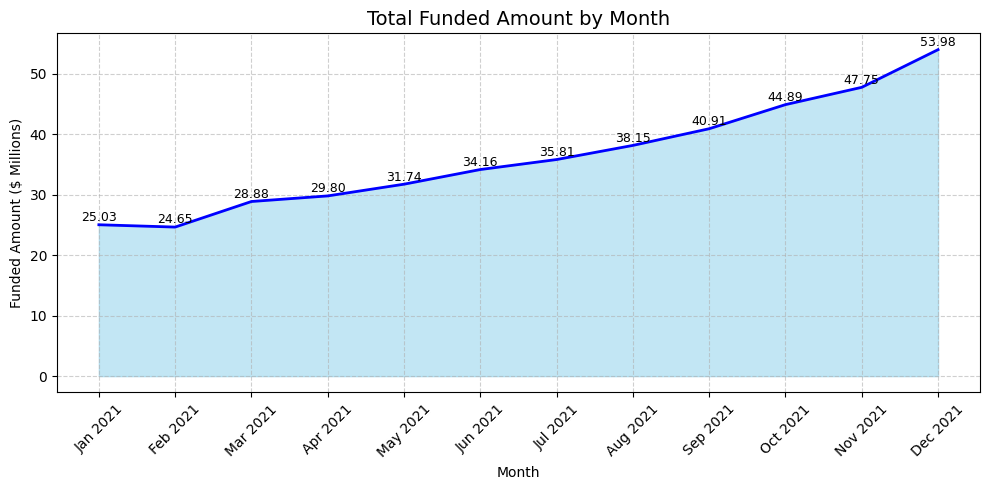

In [23]:
monthly_funded = (
    df.sort_values('issue_date')
      .assign(month_name=lambda x: x['issue_date'].dt.strftime('%b %Y'))
      .groupby('month_name', sort=False)['loan_amount']
      .sum()
      .div(1000000)
      .reset_index(name='loan_amount_millions')
)

plt.figure(figsize=(10, 5))

plt.fill_between(
    monthly_funded['month_name'],
    monthly_funded['loan_amount_millions'],
    color='skyblue',
    alpha=0.5
)

plt.plot(
    monthly_funded['month_name'],
    monthly_funded['loan_amount_millions'],
    color='blue',
    linewidth=2
)

for i, row in monthly_funded.iterrows():
    plt.text(
        i,
        row['loan_amount_millions'] + 0.1,
        f"{row['loan_amount_millions']:.2f}",
        ha='center',
        va='bottom',
        fontsize=9,
        rotation=0,
        color='black'
    )

plt.title('Total Funded Amount by Month', fontsize=14)
plt.xlabel('Month')
plt.ylabel('Funded Amount ($ Millions)')

plt.xticks(
    ticks=range(len(monthly_funded)),
    labels=monthly_funded['month_name'],
    rotation=45
)

plt.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

### Monthy Trends by Issue Date for Total Amount Received

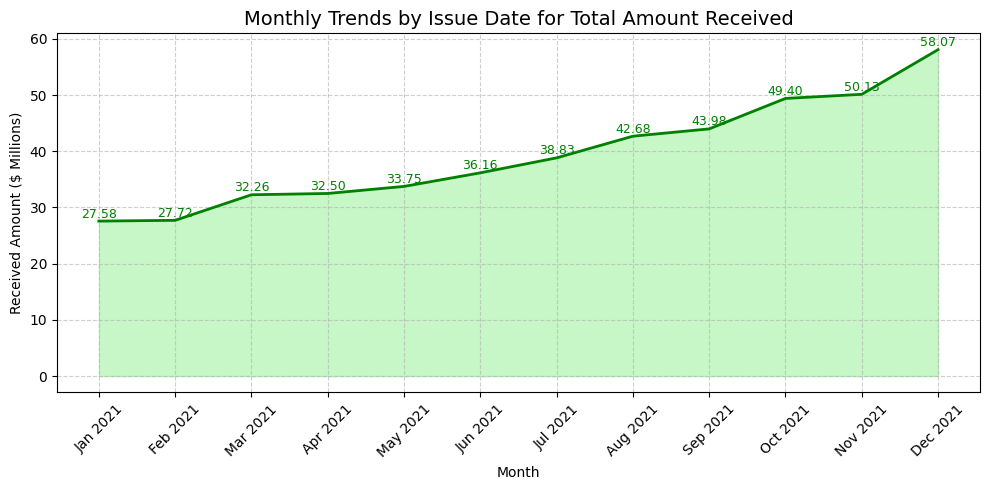

In [24]:
monthly_received = (
    df.sort_values('issue_date')
      .assign(month_name=lambda x: x['issue_date'].dt.strftime('%b %Y'))
      .groupby('month_name', sort=False)['total_payment']
      .sum()
      .div(1000000)
      .reset_index(name='received_amount_millions')
)

plt.figure(figsize=(10, 5))

plt.fill_between(
    monthly_received['month_name'],
    monthly_received['received_amount_millions'],
    color='lightgreen',
    alpha=0.5
)

plt.plot(
    monthly_received['month_name'],
    monthly_received['received_amount_millions'],
    color='green',
    linewidth=2
)

for i, row in monthly_received.iterrows():
    plt.text(
        i,
        row['received_amount_millions'] + 0.1,
        f"{row['received_amount_millions']:.2f}",
        ha='center',
        va='bottom',
        fontsize=9,
        rotation=0,
        color='green'
    )

plt.title('Monthly Trends by Issue Date for Total Amount Received', fontsize=14)
plt.xlabel('Month')
plt.ylabel('Received Amount ($ Millions)')

plt.xticks(
    ticks=range(len(monthly_received)),
    labels=monthly_received['month_name'],
    rotation=45
)

plt.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

### Monthy Trends by Issue Date for Total Loan Applications

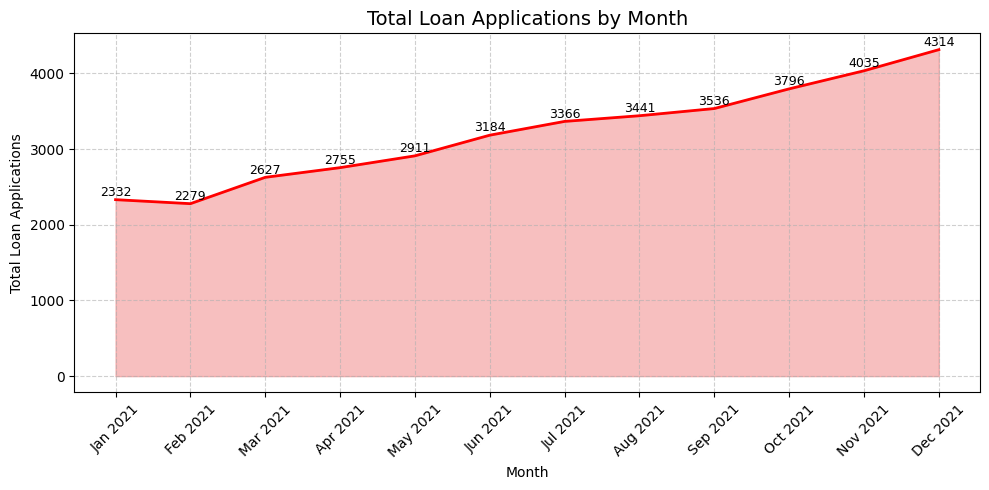

In [25]:
monthly_applications = (
    df.sort_values('issue_date')
      .assign(month_name=lambda x: x['issue_date'].dt.strftime('%b %Y'))
      .groupby('month_name', sort=False)['id']
      .count()
      .reset_index(name='total_loan_applications')
)

plt.figure(figsize=(10, 5))

plt.fill_between(
    monthly_applications['month_name'],
    monthly_applications['total_loan_applications'],
    color='lightcoral',
    alpha=0.5
)

plt.plot(
    monthly_applications['month_name'],
    monthly_applications['total_loan_applications'],
    color='red',
    linewidth=2
)

for i, row in monthly_applications.iterrows():
    plt.text(
        i,
        row['total_loan_applications'] + 10,
        f"{row['total_loan_applications']}",
        ha='center',
        va='bottom',
        fontsize=9,
        rotation=0,
        color='black'
    )

plt.title('Total Loan Applications by Month', fontsize=14)
plt.xlabel('Month')
plt.ylabel('Total Loan Applications')

plt.xticks(
    ticks=range(len(monthly_applications)),
    labels=monthly_applications['month_name'],
    rotation=45
)

plt.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

### Regional Analysis by State for Total Funded Amount

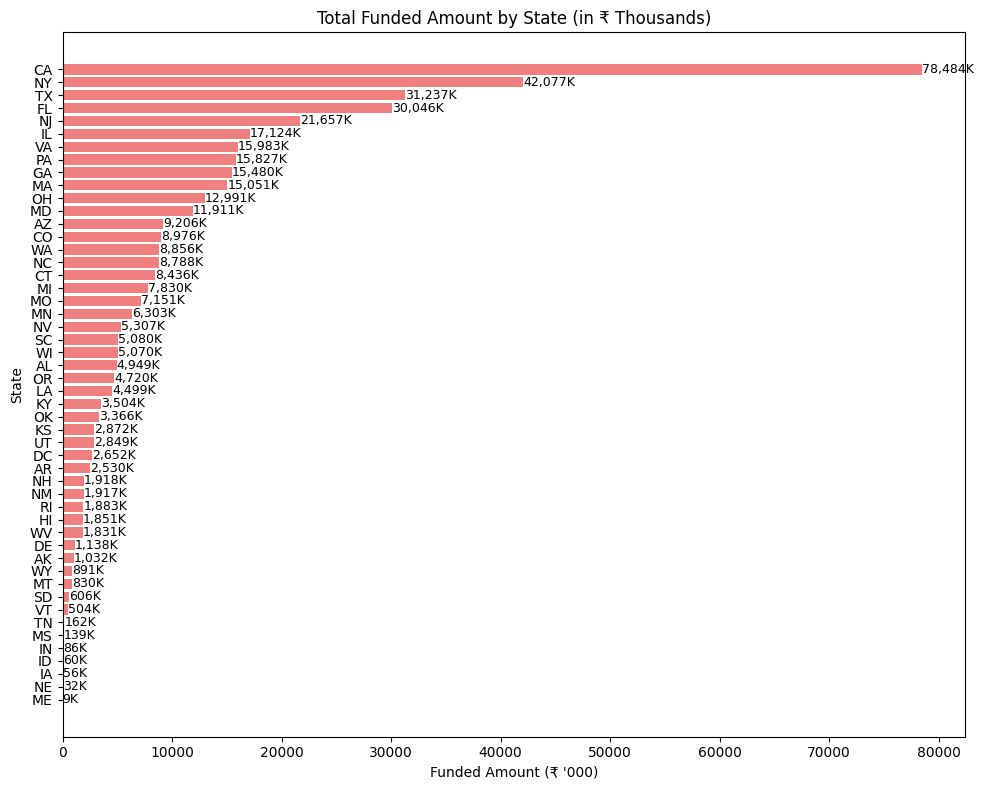

In [26]:
state_funding = df.groupby('address_state')['loan_amount'].sum().sort_values(ascending=True)
state_funding_thousands = state_funding / 1000

plt.figure(figsize=(10, 8))
bars = plt.barh(state_funding_thousands.index, state_funding_thousands.values, color='lightcoral')

for bar in bars:
    width = bar.get_width()
    plt.text(width + 10, bar.get_y() + bar.get_height() / 2,
             f'{width:,.0f}K', va='center', fontsize=9)

plt.title('Total Funded Amount by State (in ₹ Thousands)')
plt.xlabel('Funded Amount (₹ \'000)')
plt.ylabel('State')
plt.tight_layout()
plt.show()

### Regional Analysis by State for Total Amount Received


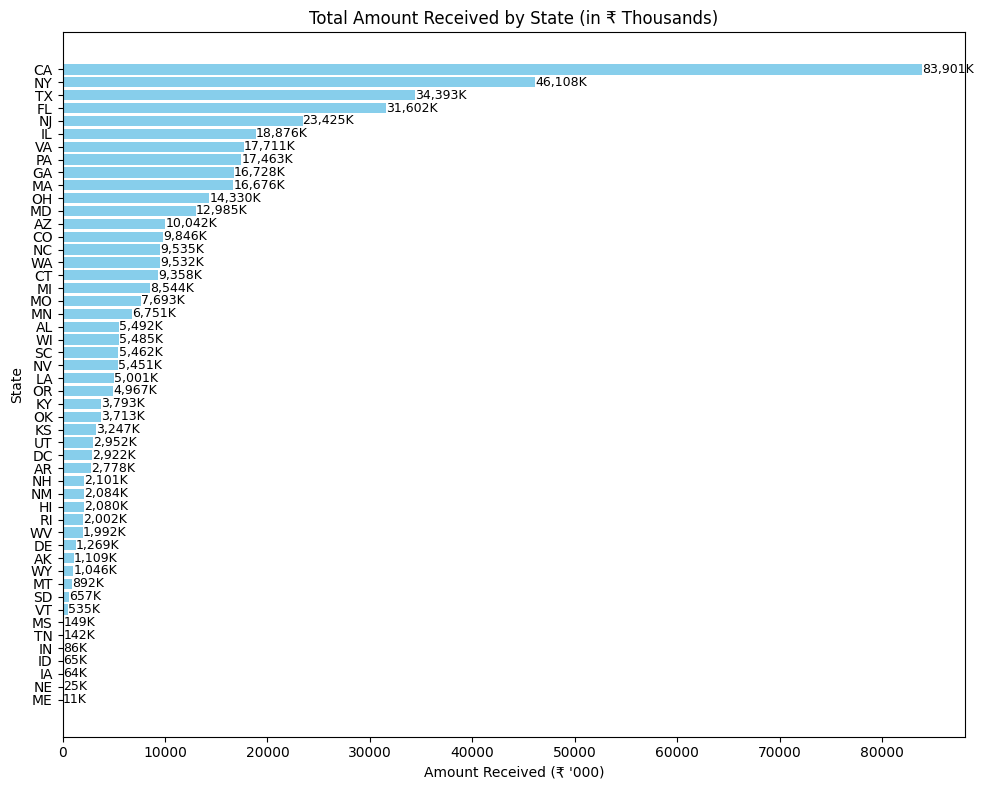

In [27]:
state_received = df.groupby('address_state')['total_payment'].sum().sort_values(ascending=True)
state_received_thousands = state_received / 1000

plt.figure(figsize=(10, 8))
bars = plt.barh(state_received_thousands.index,
                state_received_thousands.values,
                color='skyblue')

for bar in bars:
    width = bar.get_width()
    plt.text(width + 10,
             bar.get_y() + bar.get_height() / 2,
             f'{width:,.0f}K',
             va='center',
             fontsize=9)

plt.title('Total Amount Received by State (in ₹ Thousands)')
plt.xlabel('Amount Received (₹ \'000)')
plt.ylabel('State')
plt.tight_layout()
plt.show()

### Regional Analysis by State for Total Loan Applications

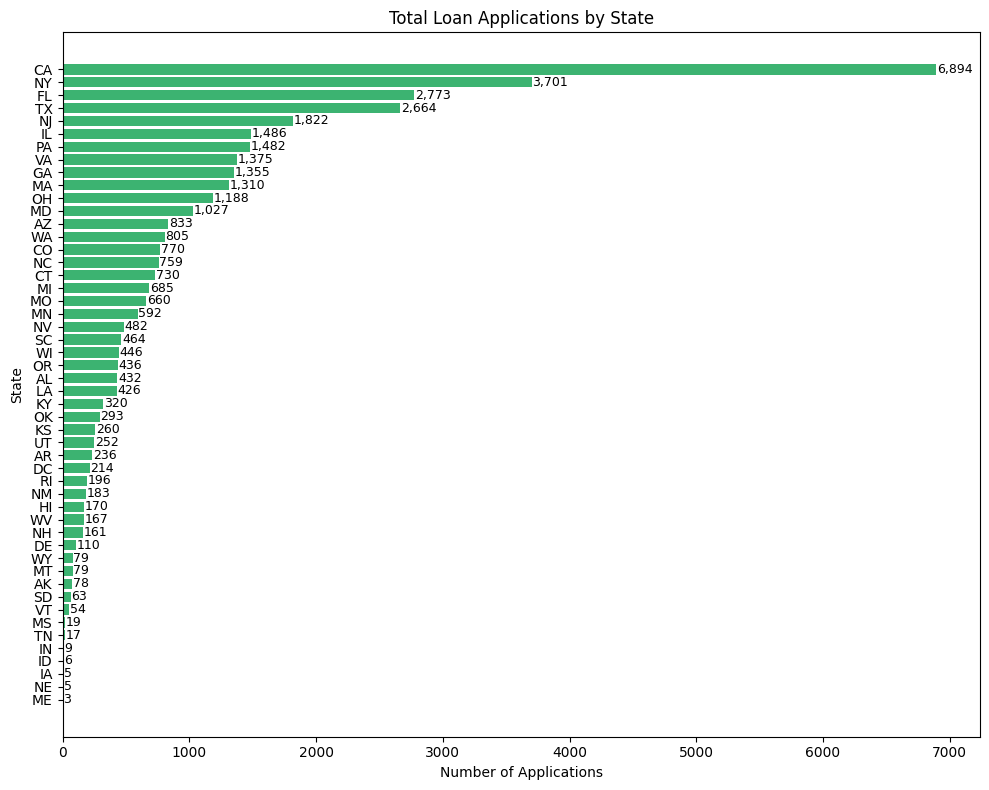

In [28]:
state_applications = df.groupby('address_state')['id'].count().sort_values(ascending=True)

plt.figure(figsize=(10, 8))
bars = plt.barh(state_applications.index,
                state_applications.values,
                color='mediumseagreen')

for bar in bars:
    width = bar.get_width()
    plt.text(width + 5,
             bar.get_y() + bar.get_height() / 2,
             f'{width:,}',
             va='center',
             fontsize=9)

plt.title('Total Loan Applications by State')
plt.xlabel('Number of Applications')
plt.ylabel('State')

plt.tight_layout()
plt.show()

### Loan Term Analysis by Total Funded Amount

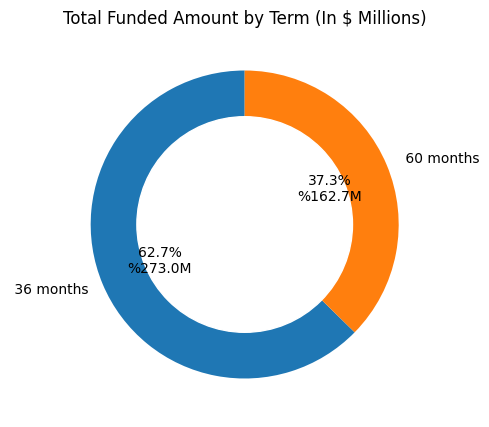

In [29]:
term_funding_millions = df.groupby('term')['loan_amount'].sum() / 1000000

plt.figure(figsize=(5, 5))
plt.pie(
    term_funding_millions,
    labels = term_funding_millions.index,
    autopct = lambda p: f"{p:.1f}%\n%{p*sum(term_funding_millions)/100:.1f}M",
    startangle = 90,
    wedgeprops = {'width': 0.4}
)
plt.gca().add_artist(plt.Circle((0, 0), 0.70, color='white'))
plt.title("Total Funded Amount by Term (In $ Millions)")
plt.show()

### Loan Term Analysis by Total Amount Received

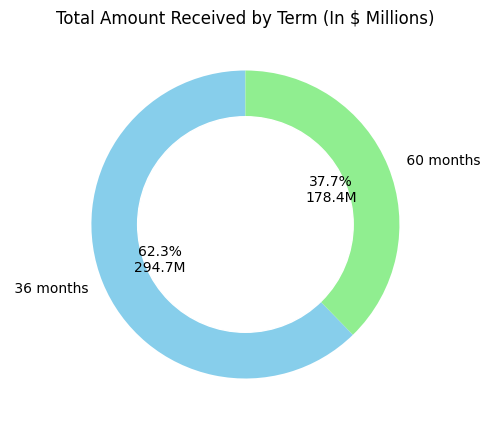

In [30]:
term_received_millions = df.groupby('term')['total_payment'].sum() / 1000000

plt.figure(figsize=(5, 5))
plt.pie(
    term_received_millions,
    labels=term_received_millions.index,
    autopct=lambda p: f"{p:.1f}%\n{p*sum(term_received_millions)/100:.1f}M",
    startangle=90,
    colors=['skyblue', 'lightgreen'],
    wedgeprops={'width': 0.4}
)

plt.gca().add_artist(plt.Circle((0, 0), 0.70, color='white'))

plt.title("Total Amount Received by Term (In $ Millions)")
plt.show()

### Loan Term Analysis by Total Loan Applications

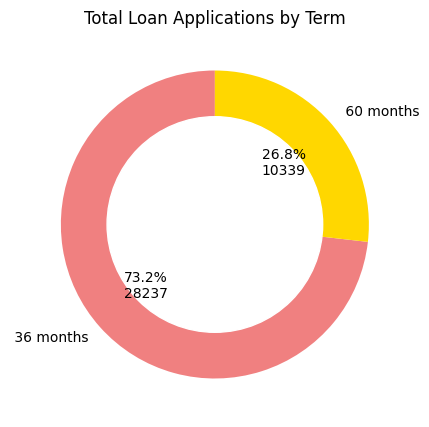

In [31]:
term_applications = df.groupby('term')['id'].count()

plt.figure(figsize=(5, 5))
plt.pie(
    term_applications,
    labels=term_applications.index,
    autopct=lambda p: f"{p:.1f}%\n{p*sum(term_applications)/100:.0f}",
    startangle=90,
    colors=['lightcoral', 'gold'],
    wedgeprops={'width': 0.4}
)

plt.gca().add_artist(plt.Circle((0, 0), 0.70, color='white'))

plt.title("Total Loan Applications by Term")
plt.show()

### Employee Length by Total Funded Amount

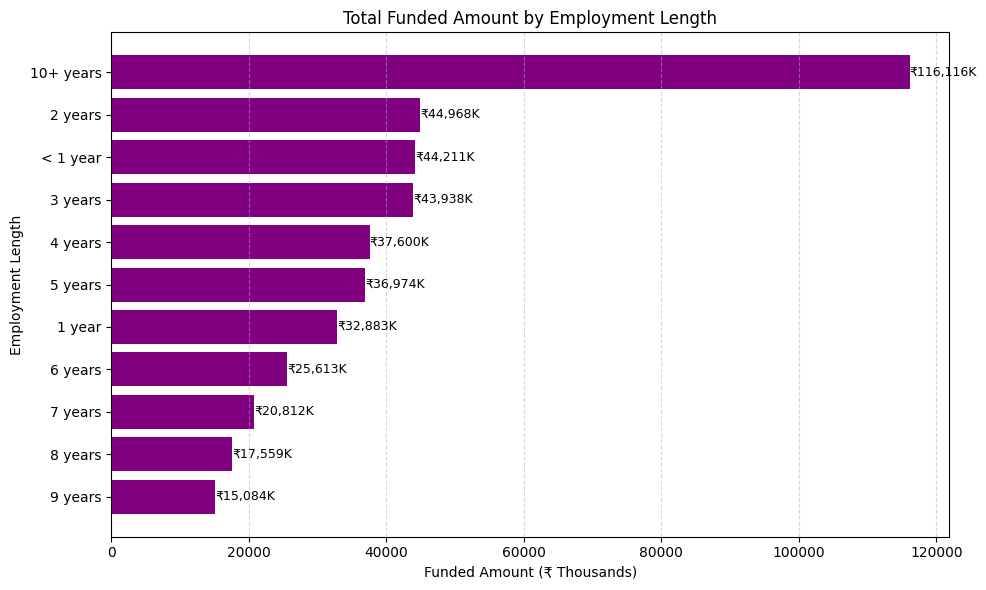

In [32]:
emp_funding_thousands = df.groupby('emp_length')['loan_amount'].sum().sort_values() / 1000

plt.figure(figsize=(10,6))

bars = plt.barh(
    emp_funding_thousands.index,
    emp_funding_thousands.values,
    color='purple'
)

for bar in bars:
    width = bar.get_width()
    plt.text(
        width + 5,
        bar.get_y() + bar.get_height() / 2,
        f"₹{width:,.0f}K",
        va='center',
        fontsize=9
    )

plt.xlabel("Funded Amount (₹ Thousands)")
plt.ylabel("Employment Length")
plt.title("Total Funded Amount by Employment Length")

plt.grid(axis='x', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

### Employee Length by Total Amount Received

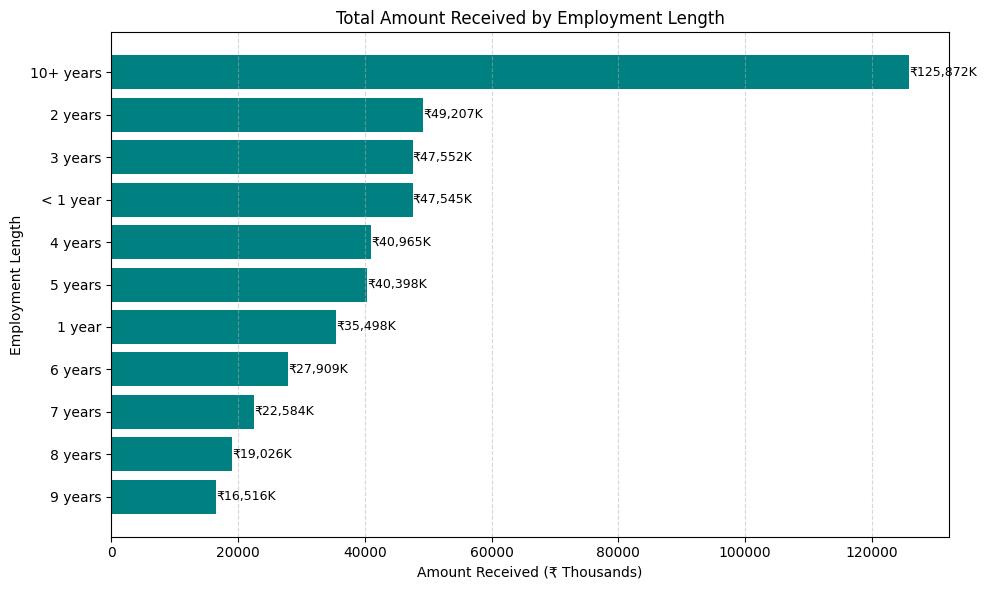

In [33]:
emp_received_thousands = df.groupby('emp_length')['total_payment'].sum().sort_values() / 1000

plt.figure(figsize=(10,6))

bars = plt.barh(
    emp_received_thousands.index,
    emp_received_thousands.values,
    color='teal'
)

for bar in bars:
    width = bar.get_width()
    plt.text(
        width + 5,
        bar.get_y() + bar.get_height() / 2,
        f"₹{width:,.0f}K",
        va='center',
        fontsize=9
    )

plt.xlabel("Amount Received (₹ Thousands)")
plt.ylabel("Employment Length")
plt.title("Total Amount Received by Employment Length")

plt.grid(axis='x', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

### Loan Purpose by Total Funded Amount

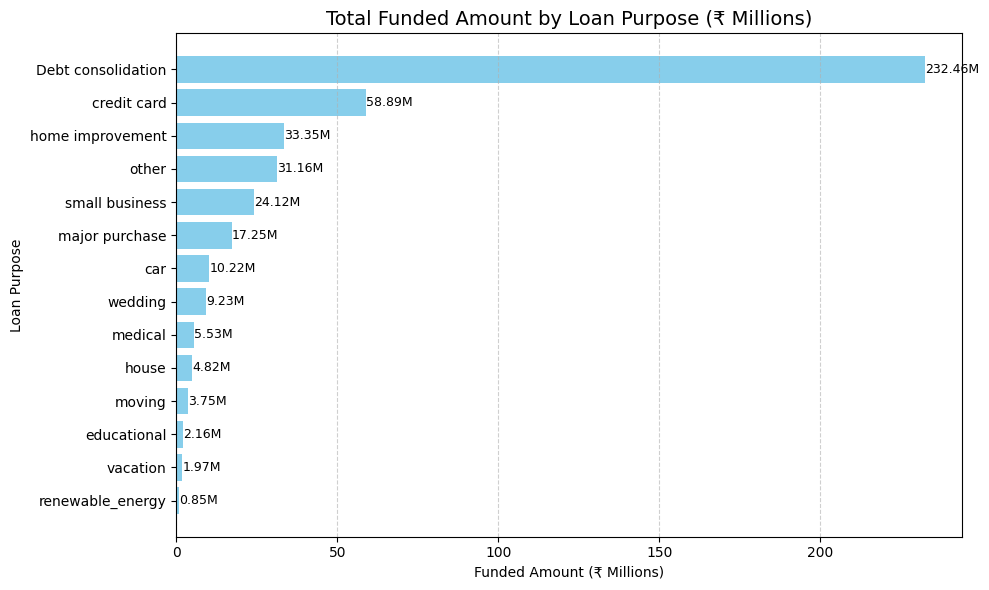

In [34]:
purpose_funding_millions = (
    df.groupby('purpose')['loan_amount']
    .sum()
    .sort_values() / 1000000
)

plt.figure(figsize=(10, 6))

bars = plt.barh(
    purpose_funding_millions.index,
    purpose_funding_millions.values,
    color='skyblue'
)

for bar in bars:
    width = bar.get_width()
    plt.text(
        width + 0.1,
        bar.get_y() + bar.get_height()/2,
        f'{width:.2f}M',
        va='center',
        fontsize=9
    )

plt.title('Total Funded Amount by Loan Purpose (₹ Millions)', fontsize=14)
plt.xlabel('Funded Amount (₹ Millions)')
plt.ylabel('Loan Purpose')

plt.grid(axis='x', linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

### Loan Purpose Analysis by Total Amount Received

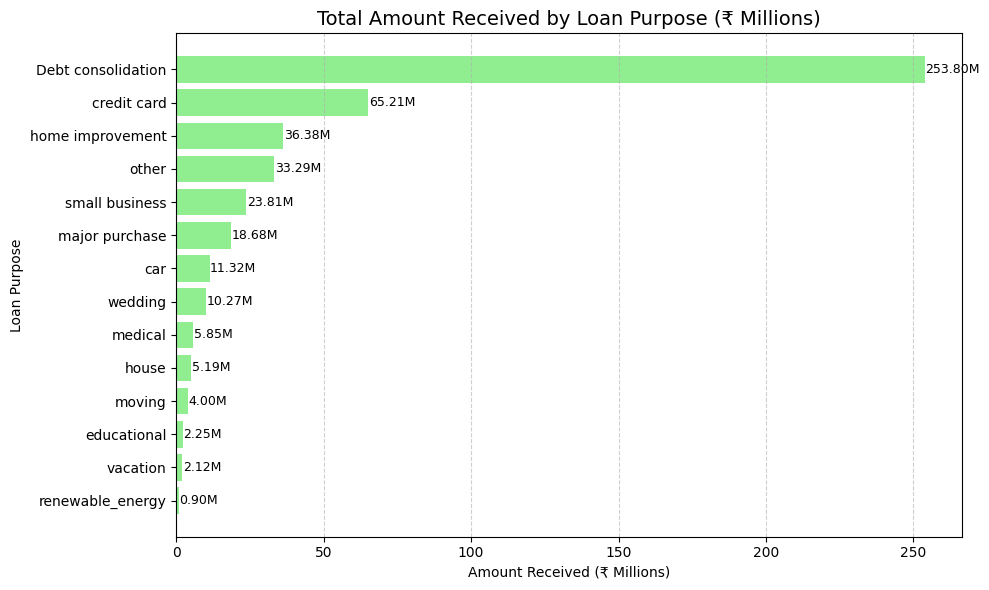

In [35]:
purpose_received_millions = (
    df.groupby('purpose')['total_payment']
    .sum()
    .sort_values() / 1000000
)

plt.figure(figsize=(10, 6))

bars = plt.barh(
    purpose_received_millions.index,
    purpose_received_millions.values,
    color='lightgreen'
)

for bar in bars:
    width = bar.get_width()
    plt.text(
        width + 0.1,
        bar.get_y() + bar.get_height()/2,
        f'{width:.2f}M',
        va='center',
        fontsize=9
    )

plt.title('Total Amount Received by Loan Purpose (₹ Millions)', fontsize=14)
plt.xlabel('Amount Received (₹ Millions)')
plt.ylabel('Loan Purpose')

plt.grid(axis='x', linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

### Loan Purpose Analysis by Total Loan Applications

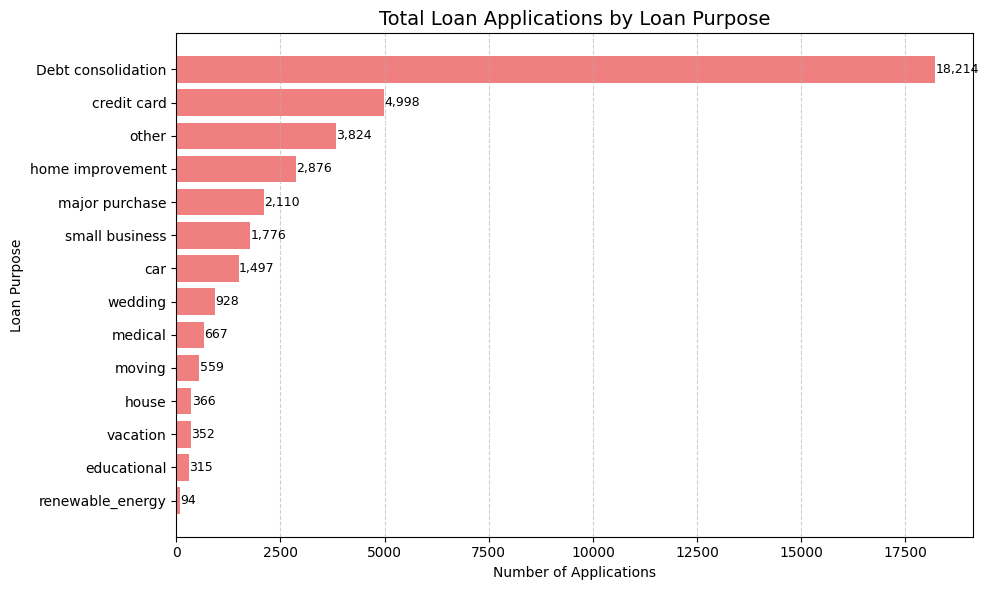

In [36]:
purpose_applications = (
    df.groupby('purpose')['id']
    .count()
    .sort_values()
)

plt.figure(figsize=(10, 6))

bars = plt.barh(
    purpose_applications.index,
    purpose_applications.values,
    color='lightcoral'
)

for bar in bars:
    width = bar.get_width()
    plt.text(
        width + 5,
        bar.get_y() + bar.get_height()/2,
        f'{width:,.0f}',
        va='center',
        fontsize=9
    )

plt.title('Total Loan Applications by Loan Purpose', fontsize=14)
plt.xlabel('Number of Applications')
plt.ylabel('Loan Purpose')

plt.grid(axis='x', linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

### Home ownership by Total Funded Amount

In [37]:
home_funding = df.groupby('home_ownership')['loan_amount'].sum().reset_index()
home_funding['loan_amount_millions'] = home_funding['loan_amount'] / 1_000_000

fig = px.treemap(
    home_funding,
    path=['home_ownership'],
    values='loan_amount_millions',
    color='loan_amount_millions',
    color_continuous_scale='Blues',
    title='Total Funded Amount by Home Ownership (₹ Millions)'
)

fig.show()

### Home Ownership by Total Amount Received

In [38]:
home_received = df.groupby('home_ownership')['total_payment'].sum().reset_index()

home_received['total_payment_millions'] = (
    home_received['total_payment'] / 1_000_000
)

fig = px.treemap(
    home_received,
    path=['home_ownership'],
    values='total_payment_millions',
    color='total_payment_millions',
    color_continuous_scale='Greens',
    title='Total Amount Received by Home Ownership (₹ Millions)'
)

fig.show()

### Home Ownership by Total Loan Applications

In [39]:
home_applications = df.groupby('home_ownership')['id'].count().reset_index()

home_applications.rename(columns={'id': 'loan_applications'}, inplace=True)

fig = px.treemap(
    home_applications,
    path=['home_ownership'],
    values='loan_applications',
    color='loan_applications',
    color_continuous_scale='Reds',
    title='Total Loan Applications by Home Ownership'
)

fig.show()